# Calculo del data drift en los procesos de modelos
1. Repaso del PSI
2. Calculo del drift en varias partes del pipeline

In [75]:
from google.colab import drive
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/MLOps 202601/scripts')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import monitoring_utils as mon_utils
import numpy as np

np.random.seed(42)
N = 10000 #número de leads

# REFERENCIA
df_ref = np.random.normal(0, 1, N)

# CASO 1: Drift pequeño
df_peq = np.random.normal(0.05, 1.02, N)

# CASO 2: Drift grande
df_grd = np.random.normal(2.0, 1.5, N)


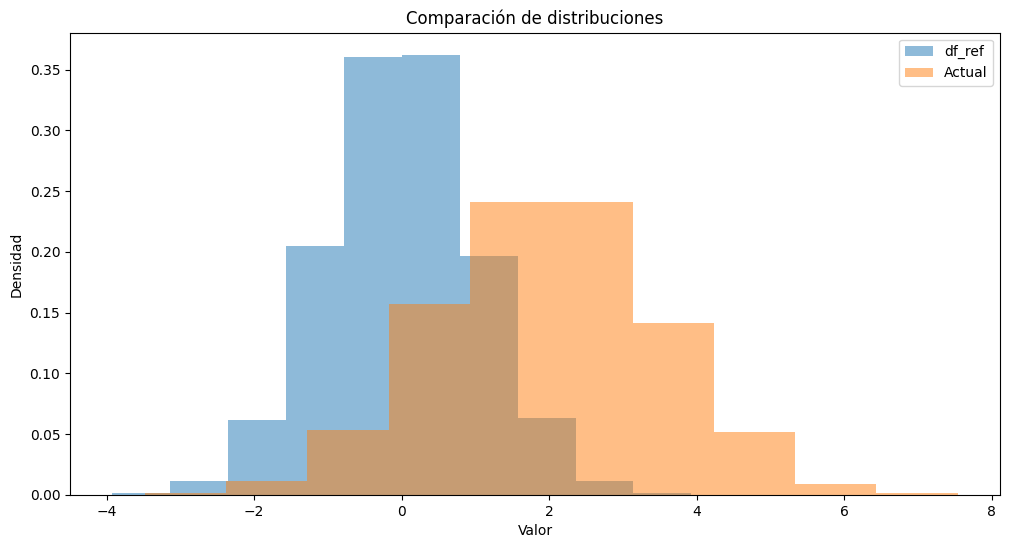

In [78]:
plt.figure(figsize=(12,6))
plt.hist(df_ref, bins=10, density=True, alpha=0.5, label='df_ref')
plt.hist(df_grd, bins=10, density=True, alpha=0.5, label='Actual')

plt.title("Comparación de distribuciones")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [79]:
import pandas as pd
df_referencia = pd.DataFrame({'col_aleatoria': df_ref})
df_distinto = pd.DataFrame({'col_aleatoria': df_grd})

#mon_utils.data_drift('PSI', df_distinto, df_referencia, 10) #el nombre de la métrica | df actual| df referencia | buckets o quantils se divide
mon_utils.data_drift(df_referencia, df_distinto, 'PSI', 10, 2)

,stage,feature,psi,drift_level,dtype,ref_missing_rate,act_missing_rate
0,PSI,col_aleatoria,1.968913,DRIFT_ALTO,numeric,0.0,0.0


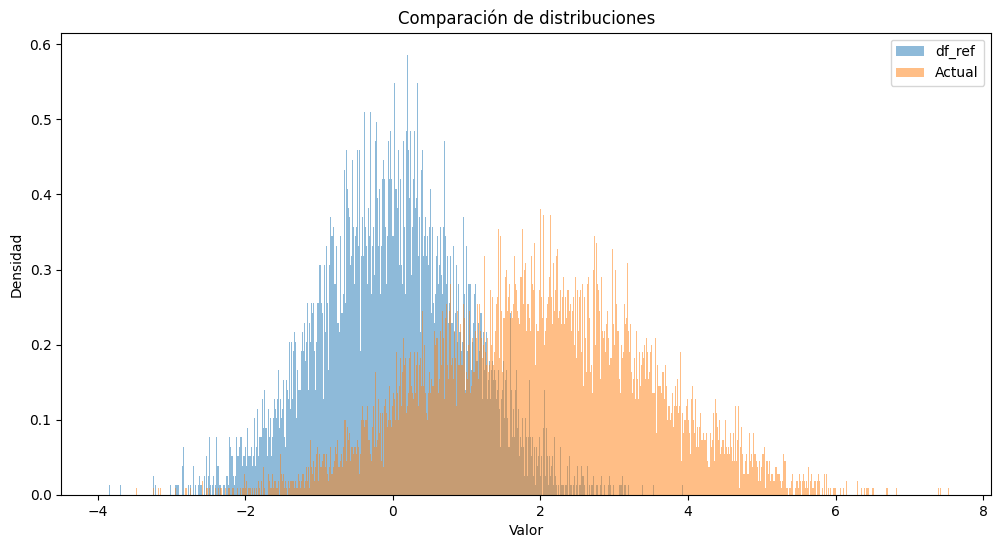

In [80]:
plt.figure(figsize=(12,6))
plt.hist(df_ref, bins=1000, density=True, alpha=0.5, label='df_ref')
plt.hist(df_grd, bins=1000, density=True, alpha=0.5, label='Actual')

plt.title("Comparación de distribuciones")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [81]:
import pandas as pd
df_referencia = pd.DataFrame({'col_aleatoria': df_ref})
df_distinto = pd.DataFrame({'col_aleatoria': df_grd})

#mon_utils.data_drift('PSI', df_distinto, df_referencia, 1000)
mon_utils.data_drift(
    df_referencia,
    df_distinto,
    "PSI",
    1000
)

,stage,feature,psi,drift_level,dtype,ref_missing_rate,act_missing_rate
0,PSI,col_aleatoria,3.568963,DRIFT_ALTO,numeric,0.0,0.0


## Cálculo del data drift en el pipeline

In [82]:
!pip install prefect

In [83]:
from prefect import flow, task #estructura del pipeline y task definir los jobs
from google.colab import drive
import sys

import preprocessing as prep
import training as aml
import inference as inf
import posprocessing as posp
import monitoring_utils as mon_utils
import pandas as pd

@task
def preprocess_data(payload):
  DIR_RAWDATA = payload['DIR_RAWDATA']
  DIR_PROCESSED = payload['DIR_PROCESSED']
  partition_id = payload['params']['partition']
  model_name = payload['params']['model_name']
  mode_type = payload['params']['mode_type']
  print("Running preprocessing")
  prep.main(model_name, DIR_RAWDATA, DIR_PROCESSED, mode_type, partition_id) #script mode
  dir_pre_processed = f'{DIR_PROCESSED}/preprocessed/vars_{partition_id}_{model_name}.csv'
  dir_pos_processed = f'{DIR_PROCESSED}/postprocessed/post_{partition_id}_{model_name}.csv'
  return dir_pre_processed, dir_pos_processed

@task
def train_model(payload):
  DATA_TRAIN_PATH = payload['TRAINING_DATA'] + '/train_vars_extrac.csv'
  DATA_TEST_PATH = payload['TRAINING_DATA'] + '/test_vars_extrac.csv'
  MODEL_DIR = payload['MODEL_DIR']
  print("Running training")
  aml.main(DATA_TRAIN_PATH, DATA_TEST_PATH, MODEL_DIR) #script mode

@task
def run_inference(payload, dir_pre_processed):
  SCORE_DIR = payload['SCORE_DIR']
  MODEL_DIR = payload['MODEL_DIR']
  partition_id = payload['params']['partition']
  model_name = payload['params']['model_name']
  print("Running inference")
  inf.main(MODEL_DIR, dir_pre_processed, SCORE_DIR) #script mode
  score_file_path = f'{SCORE_DIR}/inference_{model_name}_{partition_id}.csv'
  return score_file_path

@task
def postprocess_results(payload, dir_pos_processed, score_file_path):
  DIR_OUTPUT = payload['DIR_OUTPUT']
  partition_id = payload['params']['partition']
  print("Running postprocessing")
  posp.main(dir_pos_processed, score_file_path, DIR_OUTPUT) #script mode

@task
def calculate_shap_values(payload, dir_pre_processed):
    MODEL_DIR = payload['MODEL_DIR']
    model_name = payload['params']['model_name']
    partition_id = payload['params']['partition']

    print(f"Calculating SHAP values for model {model_name} and partition {partition_id}")

    # Assuming the model is saved in a specific format (e.g., joblib, pickle)
    # and the preprocessed data is a CSV file.
    # You might need to adjust the loading mechanism based on your actual implementation.
    model_path = f'{MODEL_DIR}/{model_name}_model.pkl' # Adjust model file extension if needed
    df_preprocessed = pd.read_csv(dir_pre_processed)

    # Assuming monitoring_utils.calculate_shap exists and handles saving or returning SHAP values
    # The function signature for calculate_shap needs to be known.
    # For demonstration, let's assume it takes the model and preprocessed DataFrame.
    # It should return SHAP values or a path to saved SHAP values.
    shap_results = mon_utils.calculate_shap(model_path, df_preprocessed)

    # You might want to save these SHAP values or a summary of them
    # For example, save to a dedicated SHAP directory
    # shap_output_path = f"{payload['DIR_PROCESSED']}/shap_values/shap_{model_name}_{partition_id}.csv"
    # shap_results.to_csv(shap_output_path, index=False) # if shap_results is a DataFrame

    print("SHAP values calculated.")
    return shap_results # or shap_output_path

@flow
def mlops_pipeline(payload): #orquestador
  # Preprocessing
  dir_pre_processed, dir_pos_processed = preprocess_data(payload)
  # Training
  if payload['params']['mode_type'] == 'training':
      train_model(payload) #script mode
  # Inference
  score_file_path = run_inference(payload, dir_pre_processed=dir_pre_processed)
  # Postprocessing for the specific partition
  final_output_path = postprocess_results(payload, dir_pos_processed=dir_pos_processed, score_file_path=score_file_path)

  # Calculate SHAP values
  # This assumes 'calculate_shap_values' function is defined as a @task
  shap_values = calculate_shap_values(payload, dir_pre_processed=dir_pre_processed)

In [91]:
payload = {
        "DIR_RAWDATA": '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial',
        "DIR_PROCESSED": '/content/drive/MyDrive/MLOps 202601/Dataset/data_preprocesada',
        "MODEL_DIR": '/content/drive/MyDrive/MLOps 202601/Dataset/models', #model registry - si hay re-entrenamiento con mismas variables solo se debe cambiar estar dirección
        "TRAINING_DATA": '/content/drive/MyDrive/MLOps 202601/Dataset/data de entrenamiento',
        "SCORE_DIR": '/content/drive/MyDrive/MLOps 202601/Dataset/models/Scores/scr_model_puro',
        "DIR_OUTPUT": '/content/drive/MyDrive/MLOps 202601/Dataset/models/Scores/scr_model_prospro',
        "params": {
            "model_name": 'extrac', # para el guardado de la data
            "mode_type": 'inference',
            "partition": 10 #p10
        }
    }

In [92]:
import os

for raiz, carpetas, archivos in os.walk("/content/drive/MyDrive"):
    for archivo in archivos:
        if archivo.endswith(".csv"):
            print(os.path.join(raiz, archivo))

/content/drive/MyDrive/chatarreo.csv
/content/drive/MyDrive/humus.csv
/content/drive/MyDrive/Ozone.csv
/content/drive/MyDrive/credit.csv
/content/drive/MyDrive/Examen/chatarreo.csv
/content/drive/MyDrive/Examen/humus.csv
/content/drive/MyDrive/Examen/Ozone.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/Semana7/MatrizCorrelacion.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/Semana7/MarketingDirecto.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/Semana2/MarketingDirecto.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/Semana2/Productos.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/Semana4/Covid19Peru.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/Semana4/MarketingDirecto.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/EPE/datos-hospital-a.csv
/content/drive/MyDrive/Visualizacion_Datos/ViualizacionDatos/EPE/datos-hospital-b.csv
/content/drive/MyDrive/MLOps 202601/Da

In [93]:
import glob

print("RAW:")
print(glob.glob(payload["DIR_RAWDATA"] + "/*"))

print("PROCESSED:")
print(glob.glob(payload["DIR_PROCESSED"] + "/*"))

print("SCORE:")
print(glob.glob(payload["SCORE_DIR"] + "/*"))

print("OUTPUT:")
print(glob.glob(payload["DIR_OUTPUT"] + "/*"))

RAW:
['/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p5_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p4_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p1_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p2_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p3_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p6_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p7_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p8_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p9_extrac.csv', '/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial/p10_extrac.csv']
PROCESSED:
[]
SCORE:
[]
OUTPUT:
[]


In [94]:
import os

print(payload["DIR_RAWDATA"])
print(os.listdir(payload["DIR_RAWDATA"]))

/content/drive/MyDrive/MLOps 202601/Dataset/DataSet Parcial
['p5_extrac.csv', 'p4_extrac.csv', 'p1_extrac.csv', 'p2_extrac.csv', 'p3_extrac.csv', 'p6_extrac.csv', 'p7_extrac.csv', 'p8_extrac.csv', 'p9_extrac.csv', 'p10_extrac.csv']


In [95]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Examen', 'chatarreo.csv', 'humus.csv', 'Ozone.csv', 'credit.csv', 'Visualizacion_Datos', 'TINVESTIGACION_GMOTTA.docx', 'Tesis_GMotta_p2.pptx', 'MLOps 202601', '.ipynb_checkpoints']


In [96]:
print(os.listdir("/content/drive/MyDrive/MLOps 202601"))

['scripts', '.ipynb_checkpoints', 'Dataset']


In [97]:
import prefect

print(prefect.__version__)

2.20.14


In [98]:
!pip uninstall -y prefect
!pip install -r /content/drive/MyDrive/MLOps\ 202601/scripts/requirements.txt

Found existing installation: prefect 2.20.25
Uninstalling prefect-2.20.25:
  Successfully uninstalled prefect-2.20.25
  Using cached prefect-2.20.25-py3-none-any.whl.metadata (12 kB)
Using cached prefect-2.20.25-py3-none-any.whl (6.0 MB)


In [99]:
!rm -rf ~/.prefect
!rm -rf /root/.prefect

In [100]:
import prefect
print(prefect.__version__)

2.20.14


In [16]:
!pip uninstall -y prefect
!pip install -q --no-cache-dir "prefect==2.20.25"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 204.0 MB/s eta 0:00:00


In [116]:
import os

os.environ["PREFECT_HOME"] = "/content/prefect_home"
os.environ["PREFECT_API_DATABASE_CONNECTION_URL"] = "sqlite+aiosqlite:////content/prefect_home/prefect.db"

!rm -rf /content/prefect_home
!mkdir -p /content/prefect_home

In [103]:
@flow(name='pipeline-mlops-con-monitoreo-e2e')
def mlops_pipeline(payload):
    ...

In [117]:
print("Existe:", "mlops_pipeline" in globals())

Existe: True


In [118]:
import traceback

try:
    resultados = mlops_pipeline(payload)
    print(resultados)
except Exception:
    traceback.print_exc()

14:09:43.569 | ERROR   | prefect.server - Encountered exception in request:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/base.py", line 146, in __init__
    self._dbapi_connection = engine.raw_connection()
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/base.py", line 3302, in raw_connection
    return self.pool.connect()
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 449, in connect
    return _ConnectionFairy._checkout(self)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 1263, in _checkout
    fairy = _ConnectionRecord.checkout(pool)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 712, in checkout
    rec = pool._do_get()
          ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/impl.py", line 308, in _do_get
    return self._create_connection()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 390, in _create_connection
    return _ConnectionRecord(self)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 674, in __init__
    self.__connect()
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 900, in __connect
    with util.safe_reraise():
         ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/util/langhelpers.py", line 146, in __exit__
    raise exc_value.with_traceback(exc_tb)
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 896, in __connect
    self.dbapi_connection = connection = pool._invoke_creator(self)
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/create.py", line 643, in connect
    return dialect.connect(*cargs, **cparams)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/default.py", line 621, in connect
    return self.loaded_dbapi.connect(*cargs, **cparams)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/dialects/sqlite/aiosqlite.py", line 352, in connect
    await_only(connection),
    ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/util/_concurrency_py3k.py", line 132, in await_only
    return current.parent.switch(awaitable)  # type: ignore[no-any-return,attr-defined] # noqa: E501
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/util/_concurrency_py3k.py", line 196, in greenlet_spawn
    value = await result
            ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiosqlite/core.py", line 168, in _connect
    self._connection = await future
                       ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiosqlite/core.py", line 63, in _connection_worker_thread
    result = function()
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiosqlite/core.py", line 466, in connector
    return sqlite3.connect(loc, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
sqlite3.OperationalError: unable to open database file

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/prefect/_vendor/starlette/middleware/errors.py", line 168, in __call__
    await self.app(scope, receive, _send)
  File "/usr/local/lib/python3.12/dist-packages/prefect/_vendor/starlette/middleware/gzip.py", line 24, in __call__
    await responder(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-pack

Traceback (most recent call last):
  File "/tmp/ipykernel_6472/477680222.py", line 4, in <cell line: 0>
    resultados = mlops_pipeline(payload)
                 ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/prefect/flows.py", line 1274, in __call__
    if PREFECT_EXPERIMENTAL_ENABLE_NEW_ENGINE.value():
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/prefect/engine.py", line 298, in enter_flow_run_engine_from_flow_call
    retval = from_sync.wait_for_call_in_loop_thread(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/prefect/_internal/concurrency/api.py", line 218, in wait_for_call_in_loop_thread
    return call.result()
           ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/prefect/_internal/concurrency/calls.py", line 318, in result
    return self.future.result(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "

In [113]:
dir_pre_processed, dir_pos_processed = preprocess_data.fn(payload)

if payload["params"]["mode_type"] == "training":
    train_model.fn(payload)

score_file_path = run_inference.fn(payload, dir_pre_processed)

final_output_path = postprocess_results.fn(
    payload,
    dir_pos_processed,
    score_file_path
)

monitoring_outputs = monitor_results.fn(payload)

resultados = {
    "preprocessed": dir_pre_processed,
    "postprocessed_input": dir_pos_processed,
    "score_puro": score_file_path,
    "score_posprocesado": final_output_path,
    "monitoring": monitoring_outputs
}

resultados

Running preprocessing
Running inference
Error: No se encontro ningún modelo en /content/drive/MyDrive/MLOps 202601/Dataset/models


IndexError: list index out of range

In [111]:
import os

os.makedirs("/content/drive/MyDrive/MLOps 202601/Dataset/data_preprocesada/preprocessed", exist_ok=True)
os.makedirs("/content/drive/MyDrive/MLOps 202601/Dataset/data_preprocesada/postprocessed", exist_ok=True)
os.makedirs("/content/drive/MyDrive/MLOps 202601/Dataset/models/Scores/scr_model_puro", exist_ok=True)
os.makedirs("/content/drive/MyDrive/MLOps 202601/Dataset/models/Scores/scr_model_prospro", exist_ok=True)
os.makedirs("/content/drive/MyDrive/MLOps 202601/Dataset/models", exist_ok=True)

In [120]:
dir_pre_processed, dir_pos_processed = preprocess_data.fn(payload)

Running preprocessing


In [123]:
import os

for raiz, carpetas, archivos in os.walk(payload["MODEL_DIR"]):
    print("\nCARPETA:", raiz)
    print("ARCHIVOS:", archivos)


CARPETA: /content/drive/MyDrive/MLOps 202601/Dataset/models
ARCHIVOS: []

CARPETA: /content/drive/MyDrive/MLOps 202601/Dataset/models/Scores
ARCHIVOS: []

CARPETA: /content/drive/MyDrive/MLOps 202601/Dataset/models/Scores/scr_model_puro
ARCHIVOS: []

CARPETA: /content/drive/MyDrive/MLOps 202601/Dataset/models/Scores/scr_model_prospro
ARCHIVOS: []


In [122]:
score_file_path = run_inference.fn(payload, dir_pre_processed)

print(score_file_path)

Running inference
Error: No se encontro ningún modelo en /content/drive/MyDrive/MLOps 202601/Dataset/models


IndexError: list index out of range

In [121]:
mlops_pipeline(payload)

14:14:20.414 | ERROR   | prefect.server - Encountered exception in request:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/base.py", line 146, in __init__
    self._dbapi_connection = engine.raw_connection()
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/base.py", line 3302, in raw_connection
    return self.pool.connect()
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 449, in connect
    return _ConnectionFairy._checkout(self)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 1263, in _checkout
    fairy = _ConnectionRecord.checkout(pool)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 712, in checkout
    rec = pool._do_get()
          ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/impl.py", line 308, in _do_get
    return self._create_connection()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 390, in _create_connection
    return _ConnectionRecord(self)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 674, in __init__
    self.__connect()
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 900, in __connect
    with util.safe_reraise():
         ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/util/langhelpers.py", line 146, in __exit__
    raise exc_value.with_traceback(exc_tb)
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/pool/base.py", line 896, in __connect
    self.dbapi_connection = connection = pool._invoke_creator(self)
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/create.py", line 643, in connect
    return dialect.connect(*cargs, **cparams)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/default.py", line 621, in connect
    return self.loaded_dbapi.connect(*cargs, **cparams)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/dialects/sqlite/aiosqlite.py", line 352, in connect
    await_only(connection),
    ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/util/_concurrency_py3k.py", line 132, in await_only
    return current.parent.switch(awaitable)  # type: ignore[no-any-return,attr-defined] # noqa: E501
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/util/_concurrency_py3k.py", line 196, in greenlet_spawn
    value = await result
            ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiosqlite/core.py", line 168, in _connect
    self._connection = await future
                       ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiosqlite/core.py", line 63, in _connection_worker_thread
    result = function()
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiosqlite/core.py", line 466, in connector
    return sqlite3.connect(loc, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
sqlite3.OperationalError: unable to open database file

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/prefect/_vendor/starlette/middleware/errors.py", line 168, in __call__
    await self.app(scope, receive, _send)
  File "/usr/local/lib/python3.12/dist-packages/prefect/_vendor/starlette/middleware/gzip.py", line 24, in __call__
    await responder(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-pack

PrefectHTTPStatusError: Server error '500 Internal Server Error' for url 'http://ephemeral-prefect/api/flows/'
Response: {'exception_message': 'Internal Server Error'}
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500

# Tarea:

- En base al código en prefect anterior y los scripts (scripts mode) desarrollen una estrategia de monitoreo.
- No toquen los scripts, excepto monitoring_utils.py
- Los indicadores que debe contener minimamente son:
  1. data drift sobre cada etapa (raw, preprocesada, score puro, score posprocesado).
  2. variación de shaps mes a mes (debe ser parte del pipeline).
- Crear un tablero de control que permita monitoreo el E2E del modelo.
  1. Que permita entender si el modelo esta scoreando sobre una distribución similar mes a mes.
  2. La estabilidad de las variables más importantes.
  3. Variación mes a mes de la importancia de variables.
- Paralelismo CPU o CPU + GPU

- El proyecto se entrega por github.
- El profesor ejecutará el colab con las indicaciones del read.me y debe estar claro el pipeline (task y flow en prefect) - el payload.
- Trabajo individual
- Entrega 26/06
